In [5]:
import os 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from locscale.include.emmer.ndimage.map_utils import load_map

parent_directory = "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_3061/epistemic_uncertainty/epoch_evolution_monte_carlo"
output_directory = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/rebuttal"

In [6]:
epochs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
variance_over_epochs = {} 
mask_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_3061/5a63_mask.mrc"
#mask_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/maps/emd_3061/feature_enhance/using_60k_dataset/emd_3061_feature_enhance_fulldataset_30epoch_mean.mrc"
mask, apix = load_map(mask_path)
for epoch in epochs: 
    epoch_directory = os.path.join(parent_directory, f"epoch_{epoch}")
    mean_prediction = os.path.join(epoch_directory, f"output_map_epoch_{epoch}_mean.mrc")
    variance_prediction = os.path.join(epoch_directory, f"output_map_epoch_{epoch}_var.mrc")
    
    # Load the EMD map
    mean_map, apix = load_map(mean_prediction)
    var_map = load_map(variance_prediction)[0]
    
    # Compute the variance of the EMD values for this epoch
    mask_bool = mask > 0.5
    variance_value = var_map[mask_bool].flatten()
    variance_over_epochs[epoch] = np.random.choice(variance_value, size=1000, replace=False)  # Sample 1000 values for plotting

/tmp/ipykernel_25357/3827631112.py:6: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(epochs)


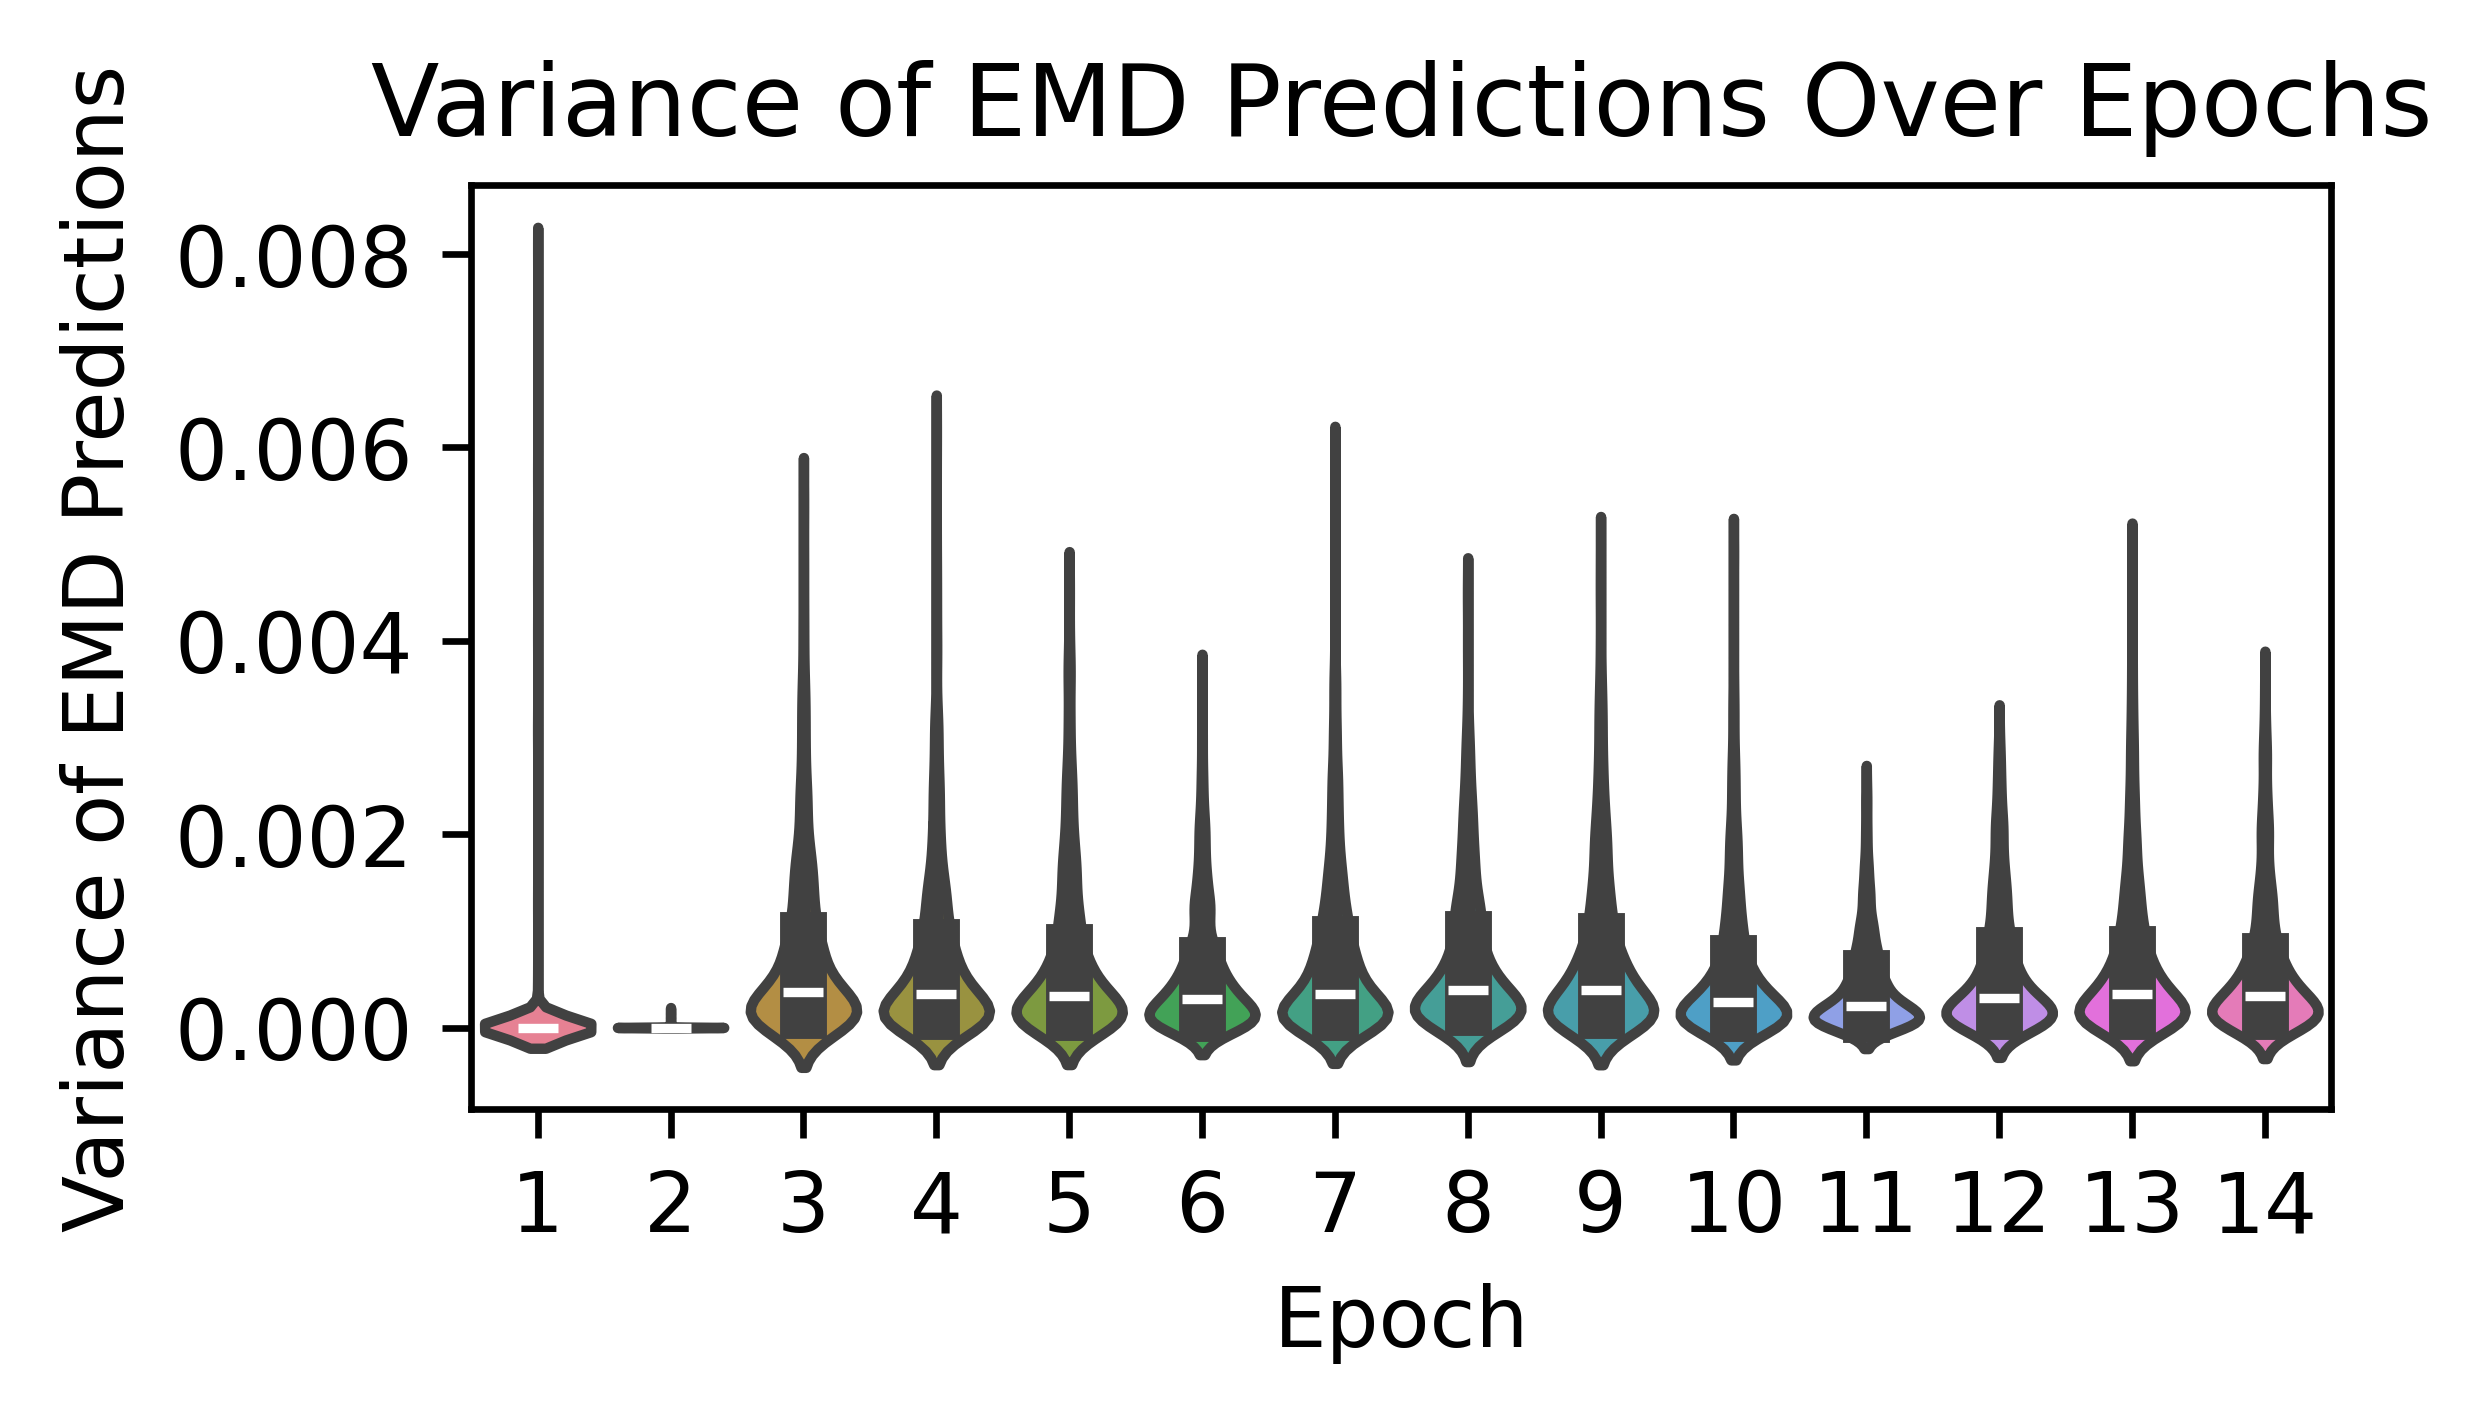

In [7]:
# plot the variance over epochs as evolution plot
from matplotlib import rcParams
rcParams["pdf.fonttype"] = 42  # TrueType fonts
fig, ax = plt.subplots(figsize=(4, 2), dpi=600)
sns.violinplot(data=[variance_over_epochs[epoch] for epoch in epochs], ax=ax)
ax.set_xticklabels(epochs)
ax.set_title("Variance of EMD Predictions Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Variance of EMD Predictions")

save_path = os.path.join(output_directory, "variance_over_epochs_violin_plot.pdf")
plt.savefig(save_path, bbox_inches="tight")
#plt.ylim(-0.001, 0.005)